# DeepWell - Data Wrangling
### Notebook 01: Data Gathering, Assessing & Cleaning
---
### Tujuan Notebook Ini
Notebook ini mencakup proses **Data Wrangling end-to-end** yang terdiri dari:
1. **Gathering** - Memuat dataset dari Google Drive
2. **Assessing** - Mengevaluasi kualitas dan struktur data
3. **Cleaning** - Membersihkan dan menyiapkan data untuk analisis

## Setup
---
### Install Library Tambahan
Menginstal library tambahan yang tidak tersedia secara default di Google Colab.

In [2]:
!pip install -q missingno

### Mount Google Drive
Menghubungkan Google Colab dengan Google Drive agar dataset yang tersimpan dapat diakses langsung dari notebook.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Setup Path
Mendefinisikan path folder proyek di Google Drive agar dataset dan file hasil olahan dapat diakses dan disimpan secara konsisten di seluruh notebook.

In [4]:
BASE_PATH = '/content/drive/MyDrive/DeepWell/'
RAW_PATH  = BASE_PATH + 'data/raw/'
PROC_PATH = BASE_PATH + 'data/processed/'

print(f'[INFO] Base path : {BASE_PATH}')
print(f'[INFO] Raw path  : {RAW_PATH}')
print(f'[INFO] Proc path : {PROC_PATH}')

[INFO] Base path : /content/drive/MyDrive/DeepWell/
[INFO] Raw path  : /content/drive/MyDrive/DeepWell/data/raw/
[INFO] Proc path : /content/drive/MyDrive/DeepWell/data/processed/


### Import Library
Mengimpor semua library yang dibutuhkan selama proses data wrangling.

In [5]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# Preprocessing & Utilities
import warnings
import os

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

print('[SUCCESS] Semua library berhasil diimport!')

[SUCCESS] Semua library berhasil diimport!


## Data Gathering
---
### Load Dataset
Memuat kedua dataset final dari Google Drive ke dalam notebook.

| # | Dataset | Peran | Nama File |
|---|---|---|---|
| 1 | Sleep Health and Lifestyle | Input SleepDisorderNet | `sleep_health_raw.csv` |
| 2 | Teen Mental Health | Input MentalHealthNet | `Teen_Mental_Health_Dataset.csv` |

In [6]:
datasets = {
    'df_sleep' : RAW_PATH + 'sleep_health_raw.csv',
    'df_mental': RAW_PATH + 'Teen_Mental_Health_Dataset.csv'
}

for name, path in datasets.items():
    try:
        globals()[name] = pd.read_csv(path)
        print(f'[SUCCESS] {name} berhasil dimuat, terdapat {globals()[name].shape[0]:,} baris x {globals()[name].shape[1]} kolom')
    except FileNotFoundError:
        print(f'[ERROR] File tidak ditemukan: {path}')

[SUCCESS] df_sleep berhasil dimuat, terdapat 1,500 baris x 13 kolom
[SUCCESS] df_mental berhasil dimuat, terdapat 1,200 baris x 13 kolom


### Preview Dataset
Menampilkan lima baris pertama dari masing-masing dataset untuk memahami struktur data.

In [7]:
print('[INFO] Preview df_sleep (Sleep Health and Lifestyle):')
display(df_sleep.head(5))

print('\n\n[INFO] Preview df_mental (Teen Mental Health Dataset):')
display(df_mental.head(5))

[INFO] Preview df_sleep (Sleep Health and Lifestyle):


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,41,Nurse,7.00,5,91,10,Normal,111/71.15,56,9476,NaN
1,2,Male,42,Software Engineer,6.70,7,123,5,Overweight,129/85.85000000000001,67,10661,NaN
2,3,Female,45,Doctor,8.70,4,49,7,Normal,119/79.35000000000001,60,5033,NaN
3,4,Male,24,Writer,8.00,6,4,5,Normal,98/62.7,97,1610,NaN
4,5,Female,18,Salesperson,8.80,6,66,4,Overweight,110/66.5,71,6574,NaN




[INFO] Preview df_mental (Teen Mental Health Dataset):


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.90,Instagram,7.40,2.90,3.01,1.50,low,2,2,1,0
1,19,female,1.90,TikTok,8.00,2.90,3.22,0.80,high,8,1,10,0
2,17,female,1.30,Instagram,7.60,0.50,3.92,0.00,high,2,4,2,0
3,15,male,7.40,TikTok,6.90,1.60,3.48,0.80,medium,1,7,9,0
4,15,female,4.70,Both,4.90,3.00,2.37,1.40,medium,3,5,2,0


## Data Assessing
---
Mengevaluasi kualitas dan struktur setiap dataset secara menyeluruh sebelum masuk ke tahap cleaning.

In [8]:
for name, df in [('df_sleep', df_sleep), ('df_mental', df_mental)]:
    print(f'========== {name} ==========')
    print(f'[INFO] Shape  : {df.shape[0]:,} baris × {df.shape[1]} kolom')
    print(f'[INFO] Memory : {df.memory_usage(deep=True).sum() / 1024:.1f} KB')
    print('[INFO] Tipe Data:')
    display(df.dtypes.to_frame(name='Dtype').T)
    print('\n')

========== df_sleep ==========
[INFO] Shape  : 1,500 baris × 13 kolom
[INFO] Memory : 490.0 KB
[INFO] Tipe Data:


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
Dtype,int64,object,int64,object,float64,int64,int64,int64,object,object,int64,int64,object




========== df_mental ==========
[INFO] Shape  : 1,200 baris × 13 kolom
[INFO] Memory : 284.5 KB
[INFO] Tipe Data:


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
Dtype,int64,object,float64,object,float64,float64,float64,float64,object,int64,int64,int64,int64


### Missing Values & Visualisasi


[INFO] df_sleep (Sleep Health) — Ditemukan missing values:


,Missing Count,Missing (%)
Sleep Disorder,961,64.07


[SUCCESS] df_mental (Teen Mental) — Tidak ada missing values!


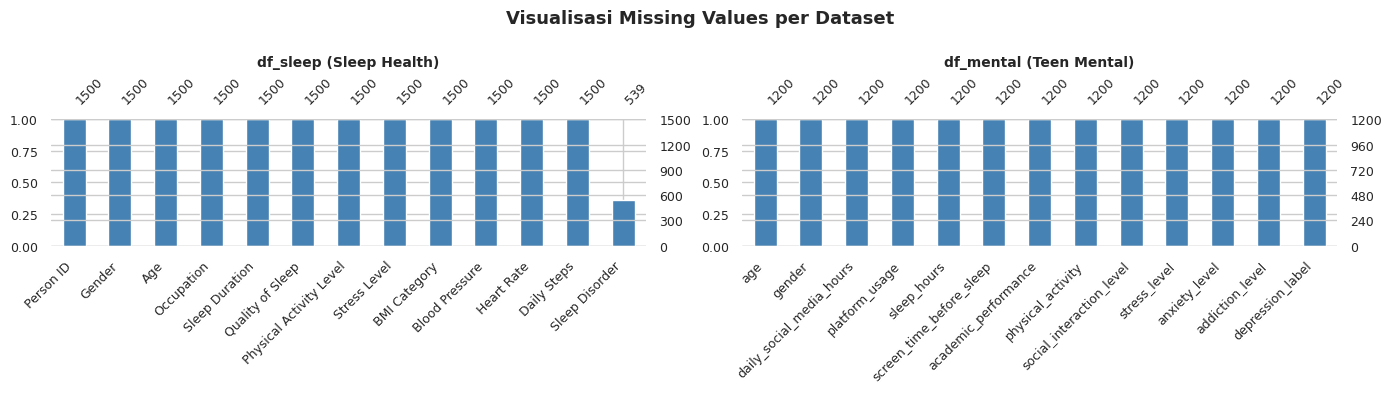

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for i, (name, df) in enumerate([('df_sleep (Sleep Health)', df_sleep), ('df_mental (Teen Mental)', df_mental)]):
    # Print Missing Values
    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(2)
    result = pd.DataFrame({'Missing Count': missing, 'Missing (%)': missing_pct}).query('`Missing Count` > 0').sort_values('Missing (%)', ascending=False)

    if result.empty:
        print(f'[SUCCESS] {name} — Tidak ada missing values!')
    else:
        print(f'[INFO] {name} — Ditemukan missing values:')
        display(result)

    # Visualisasi
    msno.bar(df, ax=axes[i], fontsize=9, color='steelblue')
    axes[i].set_title(f'{name}', fontweight='bold', fontsize=10)

plt.suptitle('Visualisasi Missing Values per Dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Duplikat & Outlier


In [10]:
def check_dup_and_outliers(df, name):
    print(f'========== {name} ==========')
    # Cek Duplikat
    dup = df.duplicated().sum()
    if dup > 0:
        print(f'[INFO] Ditemukan {dup:,} baris duplikat ({dup/len(df)*100:.2f}%)')
    else:
        print(f'[SUCCESS] Tidak ada data duplikat')

    # Cek Outlier (IQR)
    numeric_cols = df.select_dtypes(include=np.number).columns
    results = []
    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        outlier_count = ((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)).sum()
        if outlier_count > 0:
            results.append({'Kolom': col, 'Outlier Count': outlier_count, 'Outlier (%)': round(outlier_count / len(df) * 100, 2)})

    if results:
        print(f'[INFO] Ringkasan Outlier:')
        display(pd.DataFrame(results))
    else:
        print(f'[SUCCESS] Tidak ada outlier signifikan!\n')

check_dup_and_outliers(df_sleep, 'df_sleep')
check_dup_and_outliers(df_mental, 'df_mental')

========== df_sleep ==========
[SUCCESS] Tidak ada data duplikat
[INFO] Ringkasan Outlier:


,Kolom,Outlier Count,Outlier (%)
0,Sleep Duration,4,0.27
1,Quality of Sleep,23,1.53
2,Physical Activity Level,10,0.67
3,Heart Rate,6,0.40
4,Daily Steps,4,0.27


========== df_mental ==========
[SUCCESS] Tidak ada data duplikat
[INFO] Ringkasan Outlier:


,Kolom,Outlier Count,Outlier (%)
0,depression_label,31,2.58


## Data Cleaning
---
Membersihkan dan menyiapkan data berdasarkan temuan dari tahap Data Assessing dan menyesuaikan fitur dengan arsitektur model final (MentalHealthNet & SleepDisorderNet).

### Cleaning df_sleep

In [11]:
df_sleep_clean = df_sleep.copy()

# Drop Person ID
if 'Person ID' in df_sleep_clean.columns:
    df_sleep_clean.drop(columns=['Person ID'], inplace=True)
    print('[SUCCESS] Drop kolom Person ID')

# Fill Missing Values (Sleep Disorder = None)
if 'Sleep Disorder' in df_sleep_clean.columns:
    df_sleep_clean['Sleep Disorder'] = df_sleep_clean['Sleep Disorder'].fillna('None')
    print('[SUCCESS] Missing values Sleep Disorder diisi dengan "None"')

# Split Blood Pressure -> BP_Systolic & BP_Diastolic
if 'Blood Pressure' in df_sleep_clean.columns:
    df_sleep_clean[['BP_Systolic', 'BP_Diastolic']] = df_sleep_clean['Blood Pressure'].str.split('/', expand=True).astype(float)
    df_sleep_clean.drop(columns=['Blood Pressure'], inplace=True)
    print('[SUCCESS] Blood Pressure diekstraksi jadi BP_Systolic & BP_Diastolic')

# Standardisasi Teks Kategorikal
cat_cols = df_sleep_clean.select_dtypes(include='object').columns
for col in cat_cols:
    df_sleep_clean[col] = df_sleep_clean[col].str.strip().str.title()

# Harmonisasi BMI (Normal Weight -> Normal)
if 'BMI Category' in df_sleep_clean.columns:
    df_sleep_clean['BMI Category'] = df_sleep_clean['BMI Category'].replace({'Normal Weight': 'Normal'})

print('[SUCCESS] Teks kategorikal distandardisasi')
print(f'[INFO] Shape akhir df_sleep_clean: {df_sleep_clean.shape}')

[SUCCESS] Drop kolom Person ID
[SUCCESS] Missing values Sleep Disorder diisi dengan "None"
[SUCCESS] Blood Pressure diekstraksi jadi BP_Systolic & BP_Diastolic
[SUCCESS] Teks kategorikal distandardisasi
[INFO] Shape akhir df_sleep_clean: (1500, 13)


### Cleaning df_mental

In [12]:
df_mental_clean = df_mental.copy()

# Rename kolom academic_performance menjadi performance
if 'academic_performance' in df_mental_clean.columns:
    df_mental_clean.rename(columns={'academic_performance': 'performance'}, inplace=True)
    print('[SUCCESS] Kolom academic_performance diubah menjadi performance')

# Imputasi Missing Values (Bila ada)
num_cols = df_mental_clean.select_dtypes(include=['int64', 'float64']).columns
for col in num_cols:
    if df_mental_clean[col].isnull().sum() > 0:
        df_mental_clean[col] = df_mental_clean[col].fillna(df_mental_clean[col].median())

cat_cols = df_mental_clean.select_dtypes(include=['object']).columns
for col in cat_cols:
    if df_mental_clean[col].isnull().sum() > 0:
        df_mental_clean[col] = df_mental_clean[col].fillna(df_mental_clean[col].mode()[0])

# Normalisasi Teks Kategorikal
for col in cat_cols:
    df_mental_clean[col] = df_mental_clean[col].str.strip().str.lower()
print('[SUCCESS] Missing values diatasi & Teks kategorikal dinormalisasi')

# Pastikan Target sudah Biner
if 'depression_label' in df_mental_clean.columns:
    print(f'[INFO] Target depression_label unik: {df_mental_clean["depression_label"].unique()}')

print(f'[INFO] Shape akhir df_mental_clean: {df_mental_clean.shape}')

[SUCCESS] Kolom academic_performance diubah menjadi performance
[SUCCESS] Missing values diatasi & Teks kategorikal dinormalisasi
[INFO] Target depression_label unik: [0 1]
[INFO] Shape akhir df_mental_clean: (1200, 13)


## Export Dataset Bersih
---
Menyimpan kedua dataset yang telah dibersihkan ke folder `data/processed/` di Google Drive.

In [14]:
os.makedirs(PROC_PATH, exist_ok=True)

exports = {
    'sleep_health_clean.csv' : df_sleep_clean,
    'teen_mental_health_clean.csv': df_mental_clean
}

for filename, df in exports.items():
    try:
        df.to_csv(PROC_PATH + filename, index=False)
        print(f'[SUCCESS] {filename} berhasil disimpan - {df.shape[0]:,} baris x {df.shape[1]} kolom')
    except Exception as e:
        print(f'[ERROR] Gagal menyimpan {filename}: {e}')

[SUCCESS] sleep_health_clean.csv berhasil disimpan - 1,500 baris x 13 kolom
[SUCCESS] teen_mental_health_clean.csv berhasil disimpan - 1,200 baris x 13 kolom


## Ringkasan Akhir
---
### Kesimpulan Data Wrangling
Proses pembersihan data kali ini secara eksklusif difokuskan pada **2 dataset terpisah**, tanpa melakukan penggabungan (*merge*). Strategi ini selaras dengan arsitektur final *Deep Learning* yang menggunakan mekanisme Multi-input Model (MentalHealthNet dan SleepDisorderNet).

#### 1. Dataset Sleep Health and Lifestyle (Input: SleepDisorderNet)
* **Target Klasifikasi:** `Sleep Disorder` (Multi-class).
* **Perubahan Status Fitur:** `Stress Level` murni difungsikan sebagai **fitur prediktor numerik**.
* **Pembersihan:** * Menghapus identifier `Person ID`.
  * Mengekstraksi fitur teks `Blood Pressure` menjadi fitur numerik absolut (`BP_Systolic` & `BP_Diastolic`).
  * Mengisi nilai kosong (*NaN*) pada kolom target dengan label `'None'` (merepresentasikan populasi tanpa gangguan tidur).
  * Harmoniasai kategori redundant pada BMI (`Normal Weight` dilebur menjadi `Normal`).

#### 2. Dataset Teen Mental Health (Input: MentalHealthNet)
* **Target Klasifikasi:** `depression_label` (Klasifikasi Biner 0/1).
* **Perubahan Status Fitur:** `stress_level` difungsikan sebagai **fitur prediktor numerik**.
* **Pembersihan & Transformasi:** * Melakukan *rename* pada kolom `academic_performance` menjadi `performance` untuk menyelaraskan dengan *pipeline feature engineering* pada *notebook AI Engineer*.
  * Melakukan imputasi dan normalisasi *lowercase* pada seluruh kolom kategorikal (*platform_usage*, *diet_type*, dll) untuk mencegah error redundansi kelas saat proses *encoding*.

**Status Akhir:** Kedua dataset telah 100% bersih, *feature-ready*, dan tersimpan di direktori `processed`. Data siap diekspor ke tahap *Exploratory Data Analysis* (Notebook 02) dan tahap *Modeling / SMOTE* (Notebook 03).